<a href="https://colab.research.google.com/github/INDHUJA007-HUB/indhuja-day15-workshop/blob/main/Day3/miniproject_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# configure API settings

API_KEY ='83165d8cec0a18efc84051384b5df35f'

BASE_URL='https://api.openweathermap.org/data/2.5/weather'

CITIES=['Mumbai','Delhi','Coimbatore','Bangalore','Chennai','Hyderbad','Kolkata','Jaipur']

print(f'API configured for{len(CITIES)} cities')
print(f'Cities:{CITIES}')

API configured for8 cities
Cities:['Mumbai', 'Delhi', 'Coimbatore', 'Bangalore', 'Chennai', 'Hyderbad', 'Kolkata', 'Jaipur']


In [ ]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrices, or None on failure.
  """
  params = {
      'q': city,            # City name query parameter
      'appid': api_key,     # Authentication key
      'units': 'metric'     # Returns temperature in Celcius
  }
  # params in a dictionary - requests will encode it into the URL: ?q=Mumbai&appid=KEY&units=metric

  try:
    response = requests.get(BASE_URL, params = params, timeout=10)
    #requests.get() sends an HTTP GET request to BASE URL
    #timeout=10 waits max for 10 seconds; raise error if no response

    if response.status_code==200:
      #statuc_code 200 = HTTP OK = request was successful
      data = response.json()
      # .json parses the JSON text body into a Python dictionary

      return{
          'city': city,
          'temperature' : round(data['main']['temp'], 1),
          'feels_like' : round(data['main']['feels_like'], 1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' : data['weather'][0]['description'].title(),
          'visibility' : data.get('visibility', 0) #.get('visibility', 0) is safe access: return 0 if key is missing,
          #1000 - convert meters to kilimeters (integer division)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None

print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record['temperature']}°C', {record['condition']})
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...
 Fetching: Mumbai...33.0°C {'Haze'}
{'city': 'Mumbai', 'temperature': 33.0, 'feels_like': 38.8, 'humidity': 58, 'pressure': 1009, 'wind_speed': 4.63, 'condition': 'Haze', 'visibility': 7000}
 Fetching: Delhi...44.0°C {'Clear Sky'}
{'city': 'Delhi', 'temperature': 44.0, 'feels_like': 41.1, 'humidity': 10, 'pressure': 999, 'wind_speed': 5.14, 'condition': 'Clear Sky', 'visibility': 7000}
 Fetching: Coimbatore...33.9°C {'Scattered Clouds'}
{'city': 'Coimbatore', 'temperature': 33.9, 'feels_like': 38.8, 'humidity': 52, 'pressure': 1008, 'wind_speed': 6.17, 'condition': 'Scattered Clouds', 'visibility': 7000}
 Fetching: Bangalore...29.7°C {'Scattered Clouds'}
{'city': 'Bangalore', 'temperature': 29.7, 'feels_like': 31.4, 'humidity': 55, 'pressure': 1010, 'wind_speed': 6.71, 'condition': 'Scattered Clouds', 'visibility': 8000}
 Fetching: Chennai...35.6°C {'Scattered Clouds'}
{'city': 'Chennai', 'temperature': 35.6, 'feels_like': 42.6, 'humidity': 55, 'pressure': 1005, '

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

weather_df=pd.DataFrame(weather_records)

print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData  types:')
print(weather_df.dtypes)

Weather Dataframe created:
      city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
    Mumbai         33.0        38.8        58      1009        4.63             Haze        7000
     Delhi         44.0        41.1        10       999        5.14        Clear Sky        7000
Coimbatore         33.9        38.8        52      1008        6.17 Scattered Clouds        7000
 Bangalore         29.7        31.4        55      1010        6.71 Scattered Clouds        8000
   Chennai         35.6        42.6        55      1005        0.89 Scattered Clouds       10000
   Kolkata         32.0        38.9        66      1001        3.60             Haze        5000
    Jaipur         42.6        40.9        14      1001        5.66             Haze        5000

Shape: (7, 8)
Missing values: 0

Data  types:
city            object
temperature    float64
feels_like     float64
humidity         int64
pressure         int64
wind_speed     float64
condition   

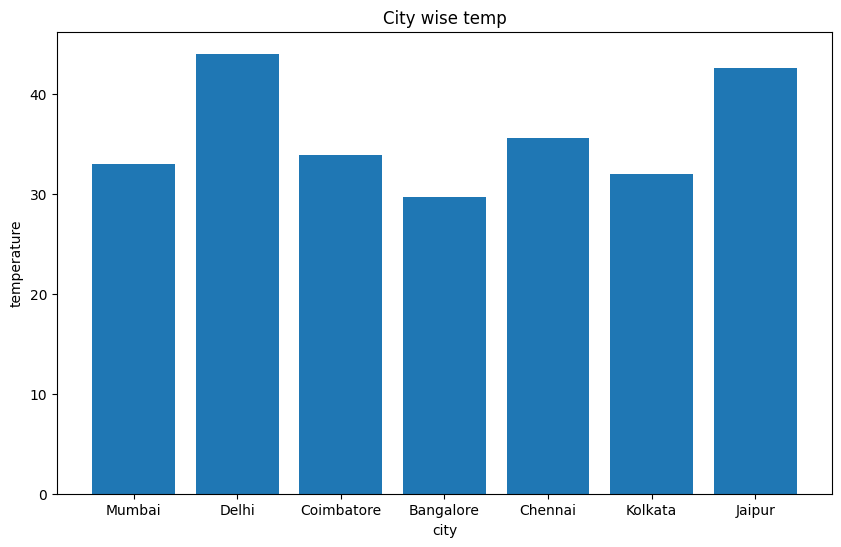

In [ ]:
import requests
plt.figure(figsize=(10, 6))
plt.bar(weather_df['city'],weather_df['temperature'])
plt.title('City wise temp')
plt.xlabel('city')
plt.ylabel('temperature')
plt.show()